In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns

`FinanceDataReader` 라이브러리 설치하고 import 한다.

FinanceDataReader는 한국과 미국을 비롯한 글로벌 금융 시장의 주식, 지수, 암호화폐 등 다양한 금융 데이이터와 종목 리스팅을 손쉽게 수집하고 분석할 수 있도록 도와주는 파이썬 오픈소스 라이브러리로 복잡한 웹 클롤링이나 API 인증 과정 없이 몇 줄의 코드로 다양한 거래소의 데이터를 판다스 데이터프레임 형태로 바로 가져올 수 있어, 주가 분석이나 퀀트 투자 등에 널리 쓰이고 있다.

!pip install finance-DataReader

In [2]:
import FinanceDataReader as fdr

FinanceDataReader에서 제공하는 종목 리스는 거래소 및 시장별로 세분화되어 있고 거래소 정보를 얻어오는 메소드는 `fdr.StockListing('시장키워드')`이며, 판다스 데이터프레임 형태로 결과를 리턴한다.

## 한국 시장 전 종목 및 특수 리스트  
fdr.StockListing(`'KRX'`) # `KRX 전체`(코스피 + 코스닥 + 코넥스)  
fdr.StockListing(`'KOSPI'`) # `코스피`  
fdr.StockListing(`'KOSDAQ'`) # `코스닥`  
fdr.StockListing(`'KONEX'`) # `코넥스`  
fdr.StockListing(`'KRX-DELISTING'`) # `상장폐지 종목`  
fdr.StockListing(`'KRX-ADMINISTRATIVE'`) # `관리종목`  
fdr.StockListing(`'KRX-MARCAP'`) # `시가총액 순 정렬`

## 미국 시장 및 주요 지수 구성 종목
fdr.StockListing(`'S&P500'`) # `S&P 500`  
fdr.StockListing(`'NASDAQ'`) # `나스닥 거래소`  
fdr.StockListing(`'NYSE'`) # `뉴욕 증권 거래소`  
fdr.StockListing(`'AMEX'`) # `아멕스 거래소`

## 글로벌 해외 주요 거래소
fdr.StockListing(`'SSE'`) # `상해(중국)`  
fdr.StockListing(`'SZSE'`) # `심천(중국)`  
fdr.StockListing(`'HKEX'`) # `홍콩`  
fdr.StockListing(`'TSE'`) # `도쿄(일본)`  
fdr.StockListing(`'HOSE'`) # `호치민(베트남)`

## ETF 리스트
fdr.StockListing(`'ETF/KR'`) # `국내 상장 ETF 전체`


In [3]:
fdr.StockListing('KRX')

,Code,ISU_CD,Name,Market,Dept,Close,ChangeCode,Changes,ChagesRatio,Open,High,Low,Volume,Amount,Marcap,Stocks,MarketId
0,005930,KR7005930003,삼성전자,KOSPI,NaN,270750,2,-3750,-1.37,283000,288000,268000,17599011,4898723994000,1582879933116000,5846278608,STK
1,000660,KR7000660001,SK하이닉스,KOSPI,NaN,1679000,1,34000,2.07,1736000,1792000,1650000,4052282,6993183274500,1226496680835000,730492365,STK
2,402340,KR7402340004,SK스퀘어,KOSPI,NaN,1161000,1,7000,0.61,1200000,1265000,1151000,528474,635707953500,153203686146000,131958386,STK
3,005935,KR7005931001,삼성전자우,KOSPI,NaN,190900,2,-4700,-2.40,197500,202000,189700,3333590,653732379100,153172662652700,802371203,STK
4,009150,KR7009150004,삼성전기,KOSPI,NaN,1474000,2,-84000,-5.39,1574000,1595000,1458000,801772,1221158655000,110098507904000,74693696,STK
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2867,002785,KR7002781003,진흥기업우B,KOSPI,NaN,1336,0,0,0.00,0,0,0,0,0,1145243248,857218,STK
2868,279060,KR7279060008,이노벡스,KONEX,일반기업부,115,0,0,0.00,0,0,0,0,0,1127904590,9807866,KNX
2869,002787,KR7002782001,진흥기업2우B,KOSPI,NaN,2895,0,0,0.00,0,0,0,0,0,853469160,294808,STK
2870,032685,KR7032681009,소프트센우,KOSDAQ,중견기업부,9500,2,-1360,-12.52,10520,11870,9500,16204,169331050,677939000,71362,KSQ


특정 종목에 대한 정보를 얻어오려면 `fdr.DataReader('종목코드'[, '시작일'[, '종료일']])` 메소드를 사용한다.

`Date`: 날짜    
`Open`: 해당 거래일의 장 시작시 체결된 첫 가격  
`High`: 해당 거래일 동안 주가가 기록한 가장 높은 가격  
`Low`: 해당 거래일 동안 주가가 기록한 가장 낮은 가격  
`Close`: 해당 거래일의 장 마감시 체결된 마지막 가격, 주가 분석 시 가장 흔하게 기준값으로 사용된다.  
`Volume`: 해당 거래일 동안 매매가 체결된 주식의 총 수량  
`Change`: 전일 종가 대비 당을 종가의 등락 변동 백분율

In [4]:
# 삼성전자(005930)의 상장일로 부터 현재까지
# fdr.DataReader('005930')
# 삼성전자(005930)의 2023-01-01로 부터 현재까지
# fdr.DataReader('005930', '2023-01-01')
# 삼성전자(005930)의 2025-01-01로 부터 2025-12-31까지
# df_samsung = fdr.DataReader('005930', '2025-01-01', '2025-12-31')
df_samsung = fdr.DataReader('005930', '2026-01-01')
df_samsung

,Open,High,Low,Close,Volume,Change
Date,,,,,,
2026-01-02,120200,128500,120200,128500,30463279,0.071726
2026-01-05,134600,138600,133600,138100,42863376,0.074708
2026-01-06,135300,139300,132700,138900,45321341,0.005793
2026-01-07,143500,144400,137600,141000,46317413,0.015119
2026-01-08,138300,144500,138300,138800,41449329,-0.015603
...,...,...,...,...,...,...
2026-08-11,229500,243000,227500,239500,23310969,0.041304
2026-08-12,243500,260500,241000,255500,27102479,0.066806
2026-08-13,267500,271000,262500,268000,35530867,0.048924


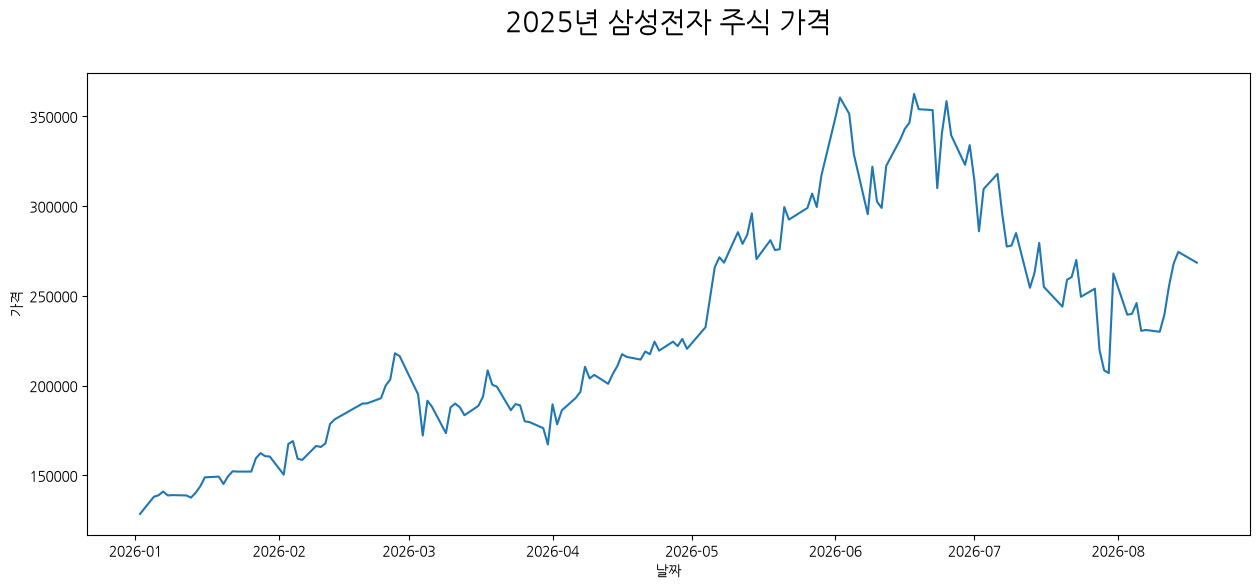

In [5]:
plt.figure(figsize=(15, 6))
sns.lineplot(x=df_samsung.index, y=df_samsung.Close)
plt.title('2025년 삼성전자 주식 가격', fontsize=20, pad=30)
plt.xlabel('날짜')
plt.ylabel('가격')
plt.show()

미쿡 주식 정보 가져오기

In [6]:
fdr.StockListing('NASDAQ').head()

100%|██████████| 3975/3975 [00:06<00:00, 636.22it/s]


,Symbol,Name,IndustryCode,Industry
0,NVDA,NVIDIA Corp,57101010,반도체
1,AAPL,Apple Inc.,57106020,전화 및 소형 장치
2,MSFT,Microsoft Corporation,57201020,소프트웨어
3,AMZN,Amazon.com Inc,53402010,백화점
4,GOOGL,Alphabet Inc. Class A,57201030,온라인 서비스


In [7]:
# df_apple = fdr.DataReader('AAPL', '2025-01-01', '2025-12-31')
df_apple = fdr.DataReader('AAPL', '2026-01-01')
df_apple

,Open,High,Low,Close,Volume,Adj Close
2025-12-31,273.059998,273.679993,271.750000,271.859985,27293600,271.122009
2026-01-02,272.260010,277.839996,269.000000,271.010010,37838100,270.274323
2026-01-05,270.640015,271.510010,266.140015,267.260010,45647200,266.534515
2026-01-06,267.000000,267.549988,262.119995,262.359985,52352100,261.647797
2026-01-07,263.200012,263.679993,259.809998,260.329987,48309800,259.623291
...,...,...,...,...,...,...
2026-08-11,307.750000,309.970001,302.790009,304.910004,37476700,304.910004
2026-08-12,305.100006,305.660004,300.570007,302.250000,41657800,302.250000
2026-08-13,304.209991,306.000000,302.049988,305.260010,40349300,305.260010
2026-08-14,306.000000,307.489990,304.299988,305.929993,28229400,305.929993


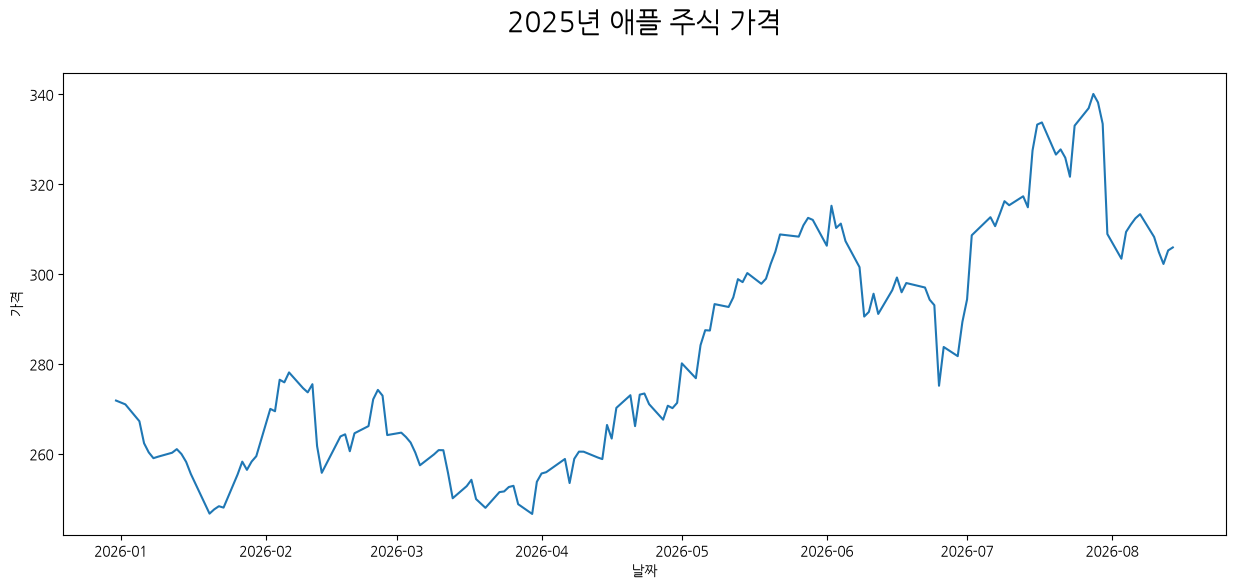

In [8]:
plt.figure(figsize=(15, 6))
sns.lineplot(x=df_apple.index, y=df_apple.Close)
plt.title('2025년 애플 주식 가격', fontsize=20, pad=30)
plt.xlabel('날짜')
plt.ylabel('가격')
plt.show()

# 시계열 데이터

## 시계열 데이터 패턴

`추세(trand)`: 시계열 데이터가 시간에 따라서 증가하거나 감소하는 경향을 보이는 패턴  
`계절성(seasonality)`: 시계열 데이터가 일정한 주기를 가지고 반복되는 패턴  
`순환성(cyclical)`: 추세와는 달리, 일정한 주기를 가지고 반복되지만 주기의 길이가 일정하지 않은 패턴  
`불규칙성(irregular)`: 지진, 홍수, 파업, 코로나와 같은 특수한 요인에 의해 발생하는 불규칙한 패턴

## 시계열 데이터 분석

`분해법`: 시계열 데이터가 가지는 추세, 계절성, 주기, 불규칙성과 같은 구성요소를 분해해서 분석  
`시간 영역 분석법`
① 자기 회귀(Auto Regressive, AR) 모형  
&nbsp;&nbsp;&nbsp;현재의 시계열 값이 과거의 자기 자신의 값들에 영향을 받는다고 가정하는 모형이다. 즉, '어제의 나, 그제의 나'가 오늘의 나를 만든다는 개념이다.  
② 이동 평균(Moving Average, MA) 모형  
&nbsp;&nbsp;&nbsp;현재의 시계열 값이 과거의 오차(white noise, 백색 잡음)들의 선형 결합으로 이루어져 있다고 보는 모형이다.  
③ 자기 회귀 이동 평균(Auto Regressive Moving Average, ARMA) 모형  
&nbsp;&nbsp;&nbsp;시계열 데이터가 있을 때 AR 특성과 MA 특성을 동시에 가지고 있을 때 사용하는 모형이다.  
④ 자기 회귀 누적 이동 평균(Auto Regressive Integrated Moving Average, ARIMA) 모형  
&nbsp;&nbsp;&nbsp;ARMA 모형의 한계를 극복하기 위해, 차분 단계를 추가한 모형이다.

## 시계열 데이터 전처리 방법

In [9]:
df = pd.DataFrame(
    {'date': ['2022-01-03', '2024-11-22', '2025-01-15'], 'name': ['홍길동', '임꺽정', '장길산']}
)
df

,date,name
0,2022-01-03,홍길동
1,2024-11-22,임꺽정
2,2025-01-15,장길산


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   date    3 non-null      str  
 1   name    3 non-null      str  
dtypes: str(2)
memory usage: 180.0 bytes


판다스의 to_datetime() 메소드로 str 타입을 datetime 타입으로 변환한다.

In [11]:
df['date'] = pd.to_datetime(df.date)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    3 non-null      datetime64[us]
 1   name    3 non-null      str           
dtypes: datetime64[us](1), str(1)
memory usage: 180.0 bytes


In [12]:
df

,date,name
0,2022-01-03,홍길동
1,2024-11-22,임꺽정
2,2025-01-15,장길산


판다스의 set_index() 메소드로 특정 시리즈(컬럼)을 인덱스로 설정할 수 있다.

datetime 타입은 date 열을 인덱스로 설정한다.

In [13]:
df = df.set_index(['date'])
df

,name
date,
2022-01-03,홍길동
2024-11-22,임꺽정
2025-01-15,장길산


In [14]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 3 entries, 2022-01-03 to 2025-01-15
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   name    3 non-null      str  
dtypes: str(1)
memory usage: 48.0 bytes


결측치 확인

isnull() 메소드와 sum() 메소드로 결측치를 확인한다.

In [15]:
df = pd.DataFrame(
    {'date': ['2022-01-03', '2024-11-22', '2024-12-01', '2025-01-15'], 'x': [0.1, 2.0, np.nan, 1.2]}
)
df['date'] = pd.to_datetime(df.date)
df = df.set_index(['date'])
df

,x
date,
2022-01-03,0.1
2024-11-22,2.0
2024-12-01,NaN
2025-01-15,1.2


In [16]:
df.isnull().sum()

x    1
dtype: int64

결측치 처리

판다스의 dropna() 메소드로 결측치를 제거할 수 있다.

`axis`: 0은 결측치가 포함된 행을 제거(기본값)하고, 1은 결측치가 포함된 열을 제거한다.  
`how`: 'any'는 axis 속성으로 지정한 축에 한 개 이상 결측치가 있으면 제거(기본값)하고, 'all'은 지정한 축의 모든 값이 결측치일 때 제거한다.  
`thresh`: 결측치가 아닌 값이 thresh 속성에 지정하는 속성값 이상 남아있는 경우 유지하고, 그렇치 않으면 제거한다.  
`subset`: 리스트 형태로 지정하며 특정 열이나 행에 대해서만 결측치 검사를 수행하고 싶을 때 사용한다.

In [17]:
df.dropna()

,x
date,
2022-01-03,0.1
2024-11-22,2.0
2025-01-15,1.2


판다스의 ffill() 메소드로 이전 값으로 결측치를 채운다.

In [18]:
df.ffill()

,x
date,
2022-01-03,0.1
2024-11-22,2.0
2024-12-01,2.0
2025-01-15,1.2


판다스의 bfill() 메소드로 다음 값으로 결측치를 채운다.

In [19]:
df.bfill()

,x
date,
2022-01-03,0.1
2024-11-22,2.0
2024-12-01,1.2
2025-01-15,1.2


판다스의 interpolate() 메소드로 이전값과 다음값의 평균으로 결측치를 채운다.

In [20]:
df.interpolate()

,x
date,
2022-01-03,0.1
2024-11-22,2.0
2024-12-01,1.6
2025-01-15,1.2


판다스의 fillna() 메소드로 특정값으로 채운다

In [21]:
df.fillna('특정값')

,x
date,
2022-01-03,0.1
2024-11-22,2.0
2024-12-01,특정값
2025-01-15,1.2


빈도 설정

In [22]:
df = pd.DataFrame(
    {'date': ['2021-01-03', '2024-11-22', '2024-12-01', '2025-01-15'], 'x': [0.1, 2.0, 1.6, 1.2]}
)
df['date'] = pd.to_datetime(df.date)
df = df.set_index(['date'])
df

,x
date,
2021-01-03,0.1
2024-11-22,2.0
2024-12-01,1.6
2025-01-15,1.2


In [23]:
df.index

DatetimeIndex(['2021-01-03', '2024-11-22', '2024-12-01', '2025-01-15'], dtype='datetime64[us]', name='date', freq=None)

판다스의 asfreq() 메소드는 시계열 데이터의 주기(frequency)를 변환할 때 사용한다.  
asfreq() 메소드가 정상적으로 실행되려면 데이터프레임의 인덱스가 `DatetimeIndex` 타입이어야 한다.

`freq(필수)` 속성은 변경하고자 하는 시계열 데이터의 주기를 지정한다.  

① 연/분기/월 단위 (macro)주기  
&nbsp;&nbsp;&nbsp;`YE`(Year-End): 매년 12월 31일(연말)  
&nbsp;&nbsp;&nbsp;`YS`(Year-Start): 매년 1월 1일(연초)  
&nbsp;&nbsp;&nbsp;`QE`(Quarter-End): 매년 분기 말  
&nbsp;&nbsp;&nbsp;`QS`(Quarter-End): 매년 분기 초  
&nbsp;&nbsp;&nbsp;`ME`(Month-End): 매월 말  
&nbsp;&nbsp;&nbsp;`MS`(Month-Start): 매월 초  

② 주/일 단위 (standard)주기  
&nbsp;&nbsp;&nbsp;`D`(Daily): 매일, 24시간 간격  
&nbsp;&nbsp;&nbsp;`B`(Business Day): 매일, 주말/공휴일을 제외한 영업일 기준  
&nbsp;&nbsp;&nbsp;`금융/주식 데이터는 주말이나 공휴일이 포함된 데이터에 'D'를 쓰면 주말 데이터가 비어서 nan이 될 수 있으므로 주말을 알아서 건너뛰는 'B'를 사용한다.`  
&nbsp;&nbsp;&nbsp;`W`(Weekly): 매주 일요일, 필요하다면 'W-MON', 'W-FRI' 처럼 특정 요일을 지정할 수 있다.

③ 시/분/초 단위 주기 (micro)주기  
&nbsp;&nbsp;&nbsp;`h`(hour): 매 시간  
&nbsp;&nbsp;&nbsp;`min`(minute)매 분  
&nbsp;&nbsp;&nbsp;`s`(second)매 초

기본 단위 앞에 `숫자`를 붙이면 원하는 배수만큼 주기를 변경할 수 있다.  
&nbsp;&nbsp;&nbsp;`3D`: 3일 간격  
&nbsp;&nbsp;&nbsp;`2h`: 2시간 간격  
&nbsp;&nbsp;&nbsp;`30min`: 30분 간격

`method` 속성은 주기를 변경할 때 생기는 결측치를 채우는 방식을 지정한다.  
`fill_value` 속성은 주기가 변경될 때 생기는 결측치를 일괄적으로 채울 특정 값을 지정한다.  

In [24]:
df.asfreq(freq='YE', method='ffill')

,x
date,
2021-12-31,0.1
2022-12-31,0.1
2023-12-31,0.1
2024-12-31,1.6


특징량 만들기

In [25]:
df = pd.DataFrame(
    {'date': ['2021-01-03', '2024-11-22', '2024-12-01', '2024-12-20', '2025-01-15'], 'x': [5, 4, 3, 2, 7]}
)
df['date'] = pd.to_datetime(df.date)
df = df.set_index(['date'])
df

,x
date,
2021-01-03,5
2024-11-22,4
2024-12-01,3
2024-12-20,2
2025-01-15,7


판다스의 rolling() 메소드는 시계열이나 순차적인 데이터에서 구간별 이동 연산을 수행한다.  
일정한 크기의 창(window)을 지정한 뒤, 이 창을 데이터의 처음부터 끝까지 슬라이싱 방식으로 이동시키면서 합계, 평균, 표준편차 등의 집계 함수를 적용할 수 있다. 주식 시장의 이동 평균선이나 센서 데이터의 노이즈 제거 등에 사용된다.

`window(필수)` 속성은 이동 윈도우의 크기(묶을 데이터의 개수)를 지정한다.  
`min_periods` 속성은 집계 함수를 적용할 데이터 개수가 부족해도 있는 만큼만 가지고 계산할 수 있게 한다. nan이 발행하지 않게하려면 1을 지정하면 된다.

In [26]:
df.rolling(window=1).mean()

,x
date,
2021-01-03,5.0
2024-11-22,4.0
2024-12-01,3.0
2024-12-20,2.0
2025-01-15,7.0


In [27]:
df.rolling(window=2, min_periods=1).mean()

,x
date,
2021-01-03,5.0
2024-11-22,4.5
2024-12-01,3.5
2024-12-20,2.5
2025-01-15,4.5


In [28]:
df.rolling(window=3).mean()

,x
date,
2021-01-03,NaN
2024-11-22,NaN
2024-12-01,4.0
2024-12-20,3.0
2025-01-15,4.0


이전 값과 차이 계산

In [29]:
df = pd.DataFrame(
    {'date': ['2021-01-03', '2024-11-22', '2024-12-01', '2024-12-20', '2025-01-15'], 'x': [5, 4, 3, 2, 7]}
)
df['date'] = pd.to_datetime(df.date)
df = df.set_index(['date'])
df

,x
date,
2021-01-03,5
2024-11-22,4
2024-12-01,3
2024-12-20,2
2025-01-15,7


판다스의 diff() 메소드는 데이터프레임이나 시리즈에서 현재 행(또는 열)의 값과 이전 행(또는 이전 열)의 값 사이의 차이를 계산한다.

`periods` 속성은 1이 기본값이고 차이를 계산할 대상과의 간격을 지정한다. 1은 현재 행과 위쪽 행(7 - 2)과 차이, -1은 현재 행과 아래쪽 행의 차이를 계산한다.  
`axis` 속성은 0이 기본값이고 0은 행 기준으로 위아래 데이터 간의 차이를 계산하고 1은 열 기준으로 좌우 데이터 간의 차이를 계산한다.

In [30]:
df2 = df.diff(periods=1, axis=0)
df2.columns = ['diff']
pd.concat([df, df2], axis=1)

,x,diff
date,,
2021-01-03,5,NaN
2024-11-22,4,-1.0
2024-12-01,3,-1.0
2024-12-20,2,-1.0
2025-01-15,7,5.0


지연값 추출

판다스의 shift() 메소드는 데이터프레임이나 시리즈에서 데이터를 지정한 칸수만큼 위나 아래로 밀어낸다.  
인덱스는 그대로 둔 채 값들만 움직이기 때문에, 시계열 데이터에서 과거의 데이터를 현재 행으로 끌어오거나 반대로 미래의 데이터를 당겨올 때 사용한다.

`periods` 속성은 1이 기본값이고 데이터를 밀어낼 칸 수를 지정한다. 양수는 과거의 데이터가 현재로 내려오고, 음수는 미래의 데이터가 위로 당겨온다.  

In [31]:
df['shift'] = df['x'].shift(periods=2)
df

,x,shift
date,,
2021-01-03,5,NaN
2024-11-22,4,NaN
2024-12-01,3,5.0
2024-12-20,2,4.0
2025-01-15,7,3.0


In [32]:
df.bfill()

,x,shift
date,,
2021-01-03,5,5.0
2024-11-22,4,5.0
2024-12-01,3,5.0
2024-12-20,2,4.0
2025-01-15,7,3.0


원-핫 인코딩

범주형(categorical) 변수를 컴퓨터가 처리할 수 있는 형태로 변환하는 방법중 하나로 모두 0으로 표시하고 현재 데이터만 1로 표시하는 방법이다.

In [33]:
df = pd.DataFrame(
    {'color': ['red', 'green', 'blue', 'green', 'red']}
)
df

,color
0,red
1,green
2,blue
3,green
4,red


판다스의 get_dummies() 메소드는 데이터 분석이나 머신러닝에서 범주형 데이터를 윈-핫 인코딩하여 파생 변수로 만든다.  
문자열이나 카테고리 형태의 데이터를 컴퓨터가 이해할 수 있도록 0과 1(또는 True와 False)로 이루어진 컬럼들을 쪼개어 주는 역할을 한다.

`data(필수)` 속성에는 원-핫 인코딩할 원본 데이터를 지정한다.  
`prefix` 속성에는 생성되는 파생 변수 이름 앞에 붙일 접두사를 지정한다.  
`columns` 속성에는 원-핫 인코딩을 적용할 열들을 지정한다. 지정하지 않으면 object, str, catrgory 타입의 모든 열이 원-핫 인코딩으로 변환된다.  
`drop_first` 속성의 기본값은 False이고, True로 설정하면 k개의 범주 중 첫 번째 범주 컬럼을 삭제하여 k-1개의 컬럼만 남긴다.  
`dummy_na` 속성의 기본값은 False이고, True로 설정하면 결측치도 하나의 독립적인 컬럼으로 만든다.  
`dtype` 속성의 기본값은 bool이고 원-핫 인코딩 결과를 True, False로 나타내고 int나 float를 지정하면 0, 1과 같이 숫자 형태로 나타낸다.

In [34]:
pd.get_dummies(data=df.color, dtype=int)

,blue,green,red
0,0,0,1
1,0,1,0
2,1,0,0
3,0,1,0
4,0,0,1


시계열 데이터 그룹화

판다스의 resample() 메소드는 시계열 데이터의 빈도를 변환할 때 사용한다.  
개념적으로는 시계열 전용 groupby라고 생각하면 이해하기 쉽다. 날짜/시간 인덱스를 기준으로 데이터를 특정 시간 간격(분, 시간, 일, 주, 월 등)으로 그룹화한 뒤, 집계 연산을 수행할 수 있다.

`rule(필수)` 속성으로 데이터를 어떤 시간 간격과 주기로 그룹화할 지 결정한다.

① 시간 및 세부 단위: 하루보다 짧은 시간 간격으로 데이터를 쪼갠다.  
`ns`: 나노초  
`us`: 마이크로초  
`ms`: 밀리초  
`s`: 초, 30s(30초 간격으로)  
`min`: 분, 5min(5분 간격으로)  
`h`: 시, 4h(4시간 간격으로)

② 일 및 주 단위: 날짜를 기준으로 묶는다.  
`D`: 달력 기준 하루, 3D(3일 간격으로)  
`B`: 영업일 기준 하루  
`W`: 주, 기본적으로 일요일 기준  

③ 월 단위: 월말 또는 월초를 기준으로 묶는다.  
`ME`: 월말, 2ME(2개월 말 간격으로)  
`MS`: 월초  
`BME`: 영업일 기준 월말  
`BMS`: 영업일 기준 월초  
`SM`(Semi-Month End): 매월 15일과 말일  

④ 분기 및 연 단위: 장기 시계열 데이터를 다룰때 사용한다.  
`QE`: 분기말  
`QS`: 분기초  
`BQE`: 영업일 기준 분기말  
`YE`: 연말  
`YS`: 연초  
`BYE`: 영업일 기준 연말

In [35]:
df_samsung.resample('BME').mean()

,Open,High,Low,Close,Volume,Change
Date,,,,,,
2026-01-30,145314.285714,148904.761905,142957.142857,146542.857143,3.094427e+07,0.014310
2026-02-27,178135.294118,183352.941176,176323.529412,180929.411765,3.167886e+07,0.018648
2026-03-31,188514.285714,192469.047619,184071.428571,187104.761905,3.285376e+07,-0.010636
2026-04-30,209950.000000,213281.818182,205836.363636,209286.363636,2.430745e+07,0.013394
2026-05-29,281777.777778,289666.666667,273222.222222,283361.111111,3.460087e+07,0.021584
2026-06-30,333357.142857,345857.142857,323571.428571,334928.571429,3.352408e+07,0.004485
2026-07-31,272045.454545,279772.727273,257531.818182,265977.272727,3.209931e+07,-0.007505
2026-08-31,250681.818182,255500.000000,241863.636364,247545.454545,2.454252e+07,0.003066


판다스의 pct_change() 메소드는 현재 요소와 직전 요소 간의 퍼센트 변화율을 계산해준다.

In [36]:
df_apple['Change'] = df_apple.Close.pct_change()
df_apple

,Open,High,Low,Close,Volume,Adj Close,Change
2025-12-31,273.059998,273.679993,271.750000,271.859985,27293600,271.122009,NaN
2026-01-02,272.260010,277.839996,269.000000,271.010010,37838100,270.274323,-0.003127
2026-01-05,270.640015,271.510010,266.140015,267.260010,45647200,266.534515,-0.013837
2026-01-06,267.000000,267.549988,262.119995,262.359985,52352100,261.647797,-0.018334
2026-01-07,263.200012,263.679993,259.809998,260.329987,48309800,259.623291,-0.007737
...,...,...,...,...,...,...,...
2026-08-11,307.750000,309.970001,302.790009,304.910004,37476700,304.910004,-0.010867
2026-08-12,305.100006,305.660004,300.570007,302.250000,41657800,302.250000,-0.008724
2026-08-13,304.209991,306.000000,302.049988,305.260010,40349300,305.260010,0.009959
2026-08-14,306.000000,307.489990,304.299988,305.929993,28229400,305.929993,0.002195


수익율 시각화

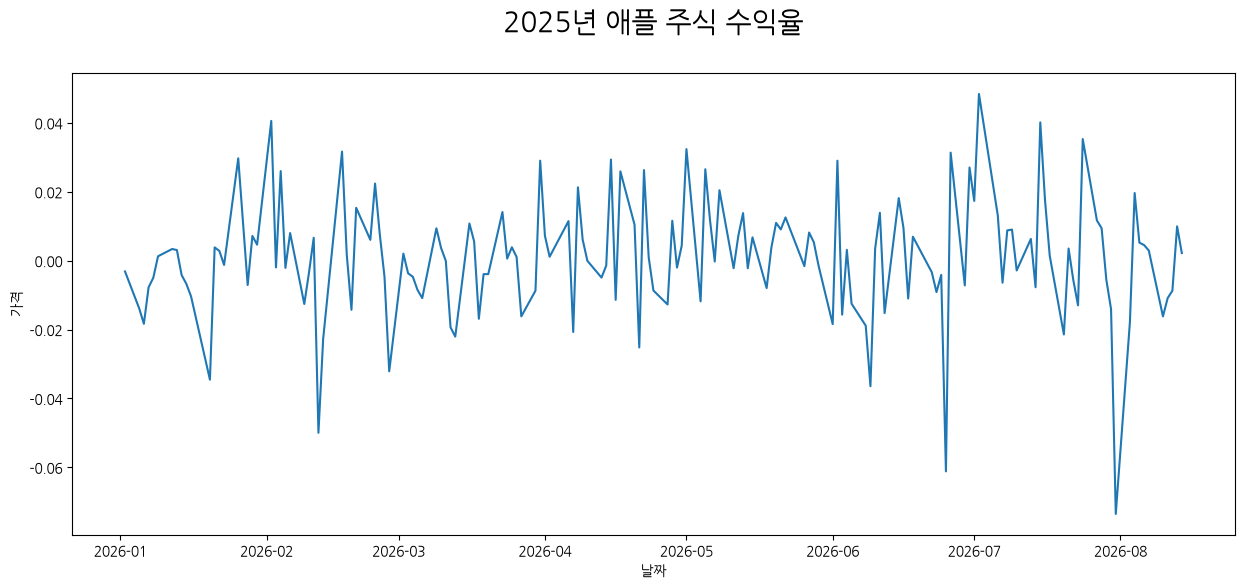

In [37]:
plt.figure(figsize=(15, 6))
sns.lineplot(x=df_apple.index, y=df_apple.Change)
plt.title('2025년 애플 주식 수익율', fontsize=20, pad=30)
plt.xlabel('날짜')
plt.ylabel('가격')
plt.show()

주가 흐름 파악하기

2달씩 종가로 이동 평균 구하기

In [38]:
df_samsung_month = df_samsung.resample('BME').mean()
df_samsung_month

,Open,High,Low,Close,Volume,Change
Date,,,,,,
2026-01-30,145314.285714,148904.761905,142957.142857,146542.857143,3.094427e+07,0.014310
2026-02-27,178135.294118,183352.941176,176323.529412,180929.411765,3.167886e+07,0.018648
2026-03-31,188514.285714,192469.047619,184071.428571,187104.761905,3.285376e+07,-0.010636
2026-04-30,209950.000000,213281.818182,205836.363636,209286.363636,2.430745e+07,0.013394
2026-05-29,281777.777778,289666.666667,273222.222222,283361.111111,3.460087e+07,0.021584
2026-06-30,333357.142857,345857.142857,323571.428571,334928.571429,3.352408e+07,0.004485
2026-07-31,272045.454545,279772.727273,257531.818182,265977.272727,3.209931e+07,-0.007505
2026-08-31,250681.818182,255500.000000,241863.636364,247545.454545,2.454252e+07,0.003066


In [39]:
df_samsung_month['MA2'] = df_samsung_month.Close.rolling(window=2, min_periods=1).mean()
df_samsung_month

,Open,High,Low,Close,Volume,Change,MA2
Date,,,,,,,
2026-01-30,145314.285714,148904.761905,142957.142857,146542.857143,3.094427e+07,0.014310,146542.857143
2026-02-27,178135.294118,183352.941176,176323.529412,180929.411765,3.167886e+07,0.018648,163736.134454
2026-03-31,188514.285714,192469.047619,184071.428571,187104.761905,3.285376e+07,-0.010636,184017.086835
2026-04-30,209950.000000,213281.818182,205836.363636,209286.363636,2.430745e+07,0.013394,198195.562771
2026-05-29,281777.777778,289666.666667,273222.222222,283361.111111,3.460087e+07,0.021584,246323.737374
2026-06-30,333357.142857,345857.142857,323571.428571,334928.571429,3.352408e+07,0.004485,309144.841270
2026-07-31,272045.454545,279772.727273,257531.818182,265977.272727,3.209931e+07,-0.007505,300452.922078
2026-08-31,250681.818182,255500.000000,241863.636364,247545.454545,2.454252e+07,0.003066,256761.363636


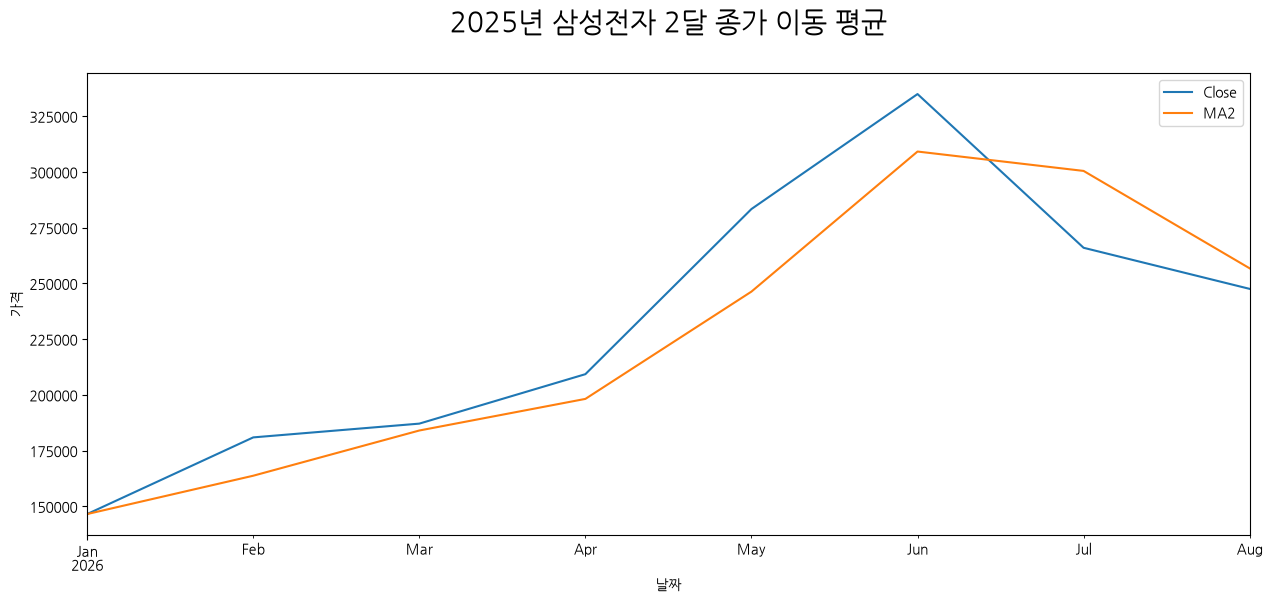

In [40]:
df_samsung_month.loc[:, ['Close', 'MA2']].plot(xlabel='날짜', ylabel='가격', figsize=(15, 6))
plt.title('2025년 삼성전자 2달 종가 이동 평균', fontsize=20, pad=30)
plt.show()

In [41]:
df_apple_month = df_apple.resample('BME').mean()
df_apple_month

,Open,High,Low,Close,Volume,Adj Close,Change
2025-12-31,273.059998,273.679993,271.750000,271.859985,2.729360e+07,271.122009,NaN
2026-01-30,258.227000,260.531498,255.170497,257.649498,5.200086e+07,256.950092,-0.002251
2026-02-27,269.262107,272.839476,266.106315,269.178422,5.204847e+07,268.631625,0.001175
2026-03-31,255.274092,257.630454,252.476820,254.906363,4.091071e+07,254.452278,-0.001754
2026-04-30,263.962857,266.673331,261.437143,264.694761,4.321612e+07,264.223240,0.003295
2026-05-29,295.766498,299.742503,294.270999,297.541499,4.906432e+07,297.206505,0.007070
2026-06-30,297.890951,301.752386,293.378095,296.419524,6.672239e+07,296.164099,-0.003356
2026-07-31,319.817276,324.747276,317.044546,322.288637,5.449369e+07,322.010921,0.003266
2026-08-31,307.596361,310.006364,304.252636,307.615002,4.530350e+07,307.481482,-0.000903


In [42]:
df_apple_month['MA2'] = df_apple_month.Close.rolling(window=2, min_periods=1).mean()
df_apple_month

,Open,High,Low,Close,Volume,Adj Close,Change,MA2
2025-12-31,273.059998,273.679993,271.750000,271.859985,2.729360e+07,271.122009,NaN,271.859985
2026-01-30,258.227000,260.531498,255.170497,257.649498,5.200086e+07,256.950092,-0.002251,264.754742
2026-02-27,269.262107,272.839476,266.106315,269.178422,5.204847e+07,268.631625,0.001175,263.413960
2026-03-31,255.274092,257.630454,252.476820,254.906363,4.091071e+07,254.452278,-0.001754,262.042392
2026-04-30,263.962857,266.673331,261.437143,264.694761,4.321612e+07,264.223240,0.003295,259.800562
2026-05-29,295.766498,299.742503,294.270999,297.541499,4.906432e+07,297.206505,0.007070,281.118130
2026-06-30,297.890951,301.752386,293.378095,296.419524,6.672239e+07,296.164099,-0.003356,296.980512
2026-07-31,319.817276,324.747276,317.044546,322.288637,5.449369e+07,322.010921,0.003266,309.354080
2026-08-31,307.596361,310.006364,304.252636,307.615002,4.530350e+07,307.481482,-0.000903,314.951820


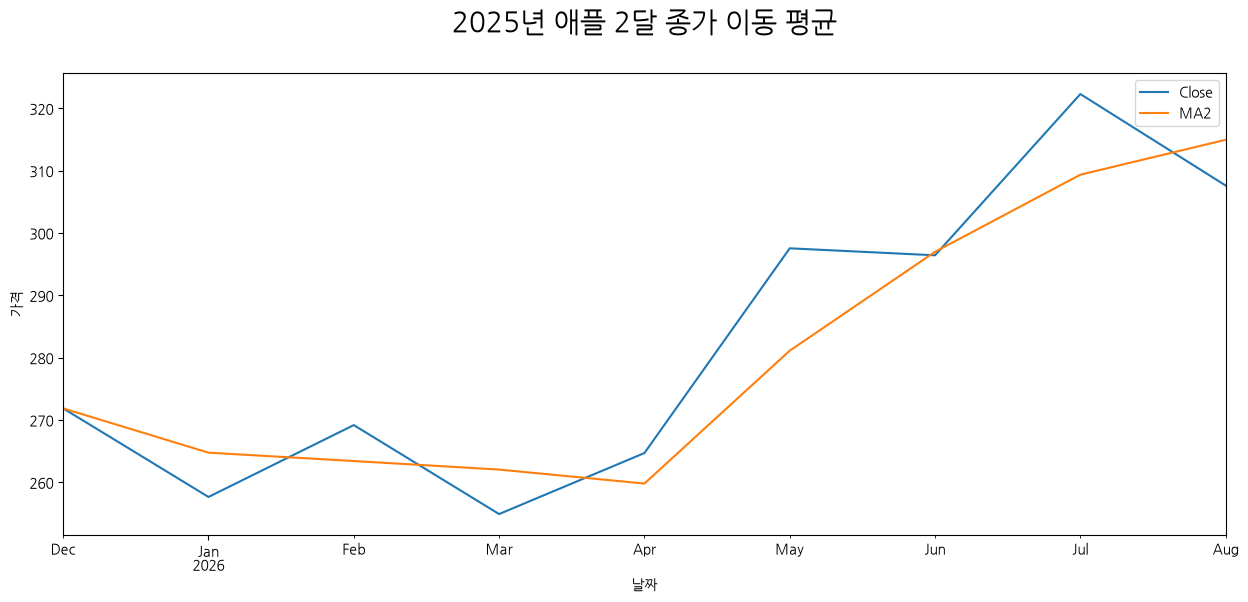

In [43]:
df_apple_month.loc[:, ['Close', 'MA2']].plot(xlabel='날짜', ylabel='가격', figsize=(15, 6))
plt.title('2025년 애플 2달 종가 이동 평균', fontsize=20, pad=30)
plt.show()

3달씩 종가로 이동 평균 구하기

In [44]:
df_samsung_month['MA3'] = df_samsung_month.Close.rolling(window=3).mean()
df_samsung_month

,Open,High,Low,Close,Volume,Change,MA2,MA3
Date,,,,,,,,
2026-01-30,145314.285714,148904.761905,142957.142857,146542.857143,3.094427e+07,0.014310,146542.857143,NaN
2026-02-27,178135.294118,183352.941176,176323.529412,180929.411765,3.167886e+07,0.018648,163736.134454,NaN
2026-03-31,188514.285714,192469.047619,184071.428571,187104.761905,3.285376e+07,-0.010636,184017.086835,171525.676937
2026-04-30,209950.000000,213281.818182,205836.363636,209286.363636,2.430745e+07,0.013394,198195.562771,192440.179102
2026-05-29,281777.777778,289666.666667,273222.222222,283361.111111,3.460087e+07,0.021584,246323.737374,226584.078884
2026-06-30,333357.142857,345857.142857,323571.428571,334928.571429,3.352408e+07,0.004485,309144.841270,275858.682059
2026-07-31,272045.454545,279772.727273,257531.818182,265977.272727,3.209931e+07,-0.007505,300452.922078,294755.651756
2026-08-31,250681.818182,255500.000000,241863.636364,247545.454545,2.454252e+07,0.003066,256761.363636,282817.099567


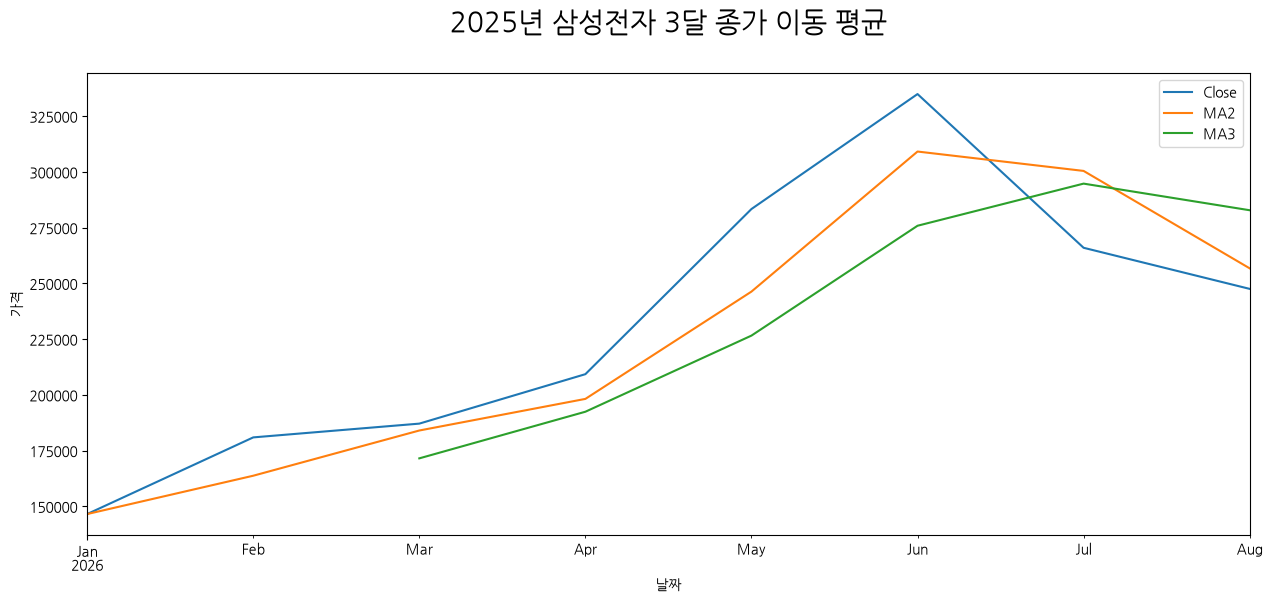

In [45]:
df_samsung_month.loc[:, ['Close', 'MA2', 'MA3']].plot(xlabel='날짜', ylabel='가격', figsize=(15, 6))
plt.title('2025년 삼성전자 3달 종가 이동 평균', fontsize=20, pad=30)
plt.show()

In [46]:
df_apple_month['MA3'] = df_apple_month.Close.rolling(window=3).mean()
df_apple_month

,Open,High,Low,Close,Volume,Adj Close,Change,MA2,MA3
2025-12-31,273.059998,273.679993,271.750000,271.859985,2.729360e+07,271.122009,NaN,271.859985,NaN
2026-01-30,258.227000,260.531498,255.170497,257.649498,5.200086e+07,256.950092,-0.002251,264.754742,NaN
2026-02-27,269.262107,272.839476,266.106315,269.178422,5.204847e+07,268.631625,0.001175,263.413960,266.229302
2026-03-31,255.274092,257.630454,252.476820,254.906363,4.091071e+07,254.452278,-0.001754,262.042392,260.578094
2026-04-30,263.962857,266.673331,261.437143,264.694761,4.321612e+07,264.223240,0.003295,259.800562,262.926515
2026-05-29,295.766498,299.742503,294.270999,297.541499,4.906432e+07,297.206505,0.007070,281.118130,272.380874
2026-06-30,297.890951,301.752386,293.378095,296.419524,6.672239e+07,296.164099,-0.003356,296.980512,286.218595
2026-07-31,319.817276,324.747276,317.044546,322.288637,5.449369e+07,322.010921,0.003266,309.354080,305.416553
2026-08-31,307.596361,310.006364,304.252636,307.615002,4.530350e+07,307.481482,-0.000903,314.951820,308.774388


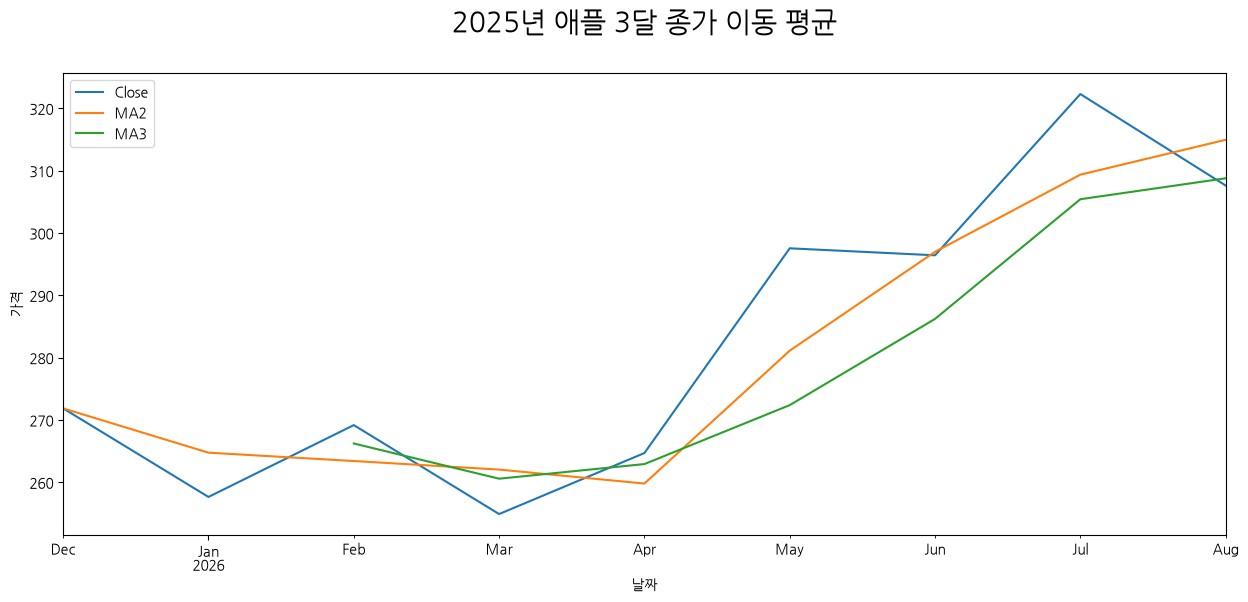

In [47]:
df_apple_month.loc[:, ['Close', 'MA2', 'MA3']].plot(xlabel='날짜', ylabel='가격', figsize=(15, 6))
plt.title('2025년 애플 3달 종가 이동 평균', fontsize=20, pad=30)
plt.show()

상승장인지 하락장인지 판별한다.

In [48]:
last_close = df_samsung_month.Close.iloc[-3] # 2달 전 종가
print(last_close)
price = df_samsung_month.Close.iloc[-1] # 오늘 종가
print(price)

if price > last_close:
    print('상승장')
elif price < last_close:
    print('하락장')
else:
    print('변화없음')

334928.5714285714
247545.45454545456
하락장


In [49]:
last_close = df_apple_month.Close.iloc[-3] # 2달 전 종가
print(last_close)
price = df_apple_month.Close.iloc[-1] # 오늘 종가
print(price)

if price > last_close:
    print('상승장')
elif price < last_close:
    print('하락장')
else:
    print('변화없음')

296.41952369326634
307.61500244140626
상승장
